
# Pass Network



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba

from mplsoccer import Pitch, FontManager, Sbopen

Set team and match info, and get event and tactics dataframes for the defined match_id



In [3]:
parser = Sbopen()
events, related, freeze, players = parser.event(267569)
TEAM = 'Real Madrid'
OPPONENT = 'versus FC Barcelona, 2016/17 La Liga'

Adding on the last tactics id and formation for the team for each event



In [4]:
events.loc[events.tactics_formation.notnull(), 'tactics_id'] = events.loc[
    events.tactics_formation.notnull(), 'id']
events[['tactics_id', 'tactics_formation']] = events.groupby('team_name')[[
    'tactics_id', 'tactics_formation']].ffill()

Add the abbreviated player position to the players dataframe



In [6]:
formation_dict = {1: 'Navas', 2: 'Carvajal', 3: 'Nacho', 4: 'CB', 5: 'Ramos', 6: 'Marcelo', 7: 'RWB',
                  8: 'LWB', 9: 'RDM', 10: 'Casemiro', 11: 'LDM', 12: 'RM', 13: 'Modric',
                  14: 'CM', 15: 'Kroos', 16: 'LM', 17: 'Bale', 18: 'RAM', 19: 'CAM',
                  20: 'LAM', 21: 'Ronaldo', 22: 'RCF', 23: 'Benzema', 24: 'LCF', 25: 'SS'}
players['position_abbreviation'] = players.position_id.map(formation_dict)

Add on the subsitutions to the players dataframe, i.e. where players are subbed on
but the formation doesn't change



In [7]:
sub = events.loc[events.type_name == 'Substitution',
                 ['tactics_id', 'player_id', 'substitution_replacement_id',
                  'substitution_replacement_name']]
players_sub = players.merge(sub.rename({'tactics_id': 'id'}, axis='columns'),
                            on=['id', 'player_id'], how='inner', validate='1:1')
players_sub = (players_sub[['id', 'substitution_replacement_id', 'position_abbreviation']]
               .rename({'substitution_replacement_id': 'player_id'}, axis='columns'))
players = pd.concat([players, players_sub])
players.rename({'id': 'tactics_id'}, axis='columns', inplace=True)
players = players[['tactics_id', 'player_id', 'position_abbreviation']]

Add player position information to the events dataframe



In [8]:
# add on the position the player was playing in the formation to the events dataframe
events = events.merge(players, on=['tactics_id', 'player_id'], how='left', validate='m:1')
# add on the position the receipient was playing in the formation to the events dataframe
events = events.merge(players.rename({'player_id': 'pass_recipient_id'},
                                     axis='columns'), on=['tactics_id', 'pass_recipient_id'],
                      how='left', validate='m:1', suffixes=['', '_receipt'])

In [9]:
events

,id,index,period,timestamp,minute,second,possession,duration,match_id,type_id,...,foul_won_defensive,pass_no_touch,pass_cut_back,bad_behaviour_card_id,bad_behaviour_card_name,block_offensive,shot_one_on_one,tactics_id,position_abbreviation,position_abbreviation_receipt
0,aba78936-4af5-4fff-ab91-8ce00b78a5b2,1,1,00:00:00,0,0,1,0.0000,267569,35,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,aba78936-4af5-4fff-ab91-8ce00b78a5b2,NaN,NaN
1,31ade910-9d72-43f3-8c46-0e06366f8fb1,2,1,00:00:00,0,0,1,0.0000,267569,35,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31ade910-9d72-43f3-8c46-0e06366f8fb1,NaN,NaN
2,9a109cd7-5a42-49ef-9d72-7ffb46734bb6,3,1,00:00:00,0,0,1,0.0000,267569,18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,aba78936-4af5-4fff-ab91-8ce00b78a5b2,NaN,NaN
3,0eb97a16-3a3b-42c0-a39c-8354b43b7659,4,1,00:00:00,0,0,1,0.0000,267569,18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31ade910-9d72-43f3-8c46-0e06366f8fb1,NaN,NaN
4,37769770-625d-41f8-b555-292ed8486fbb,5,1,00:00:00.612000,0,0,2,1.1761,267569,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,aba78936-4af5-4fff-ab91-8ce00b78a5b2,Benzema,Kroos
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3662,87a8d477-9df0-4580-9335-481f6ec22060,3663,2,00:46:47.260000,91,47,203,0.6669,267569,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,cbf97325-9dff-4e0f-9b6e-cc91649f1a6b,CAM,NaN
3663,7f630a26-2d91-4dda-b125-d4fd6014fa4e,3664,2,00:46:47.927000,91,47,203,0.0000,267569,23,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0dc7eeaa-a243-4f58-8760-7ac21cee1029,Navas,NaN
3664,f53127e0-aa2e-4fa7-9b28-17aa9fd37f8e,3665,2,00:47:27.905000,92,27,203,0.0000,267569,24,...,NaN,NaN,NaN,7.0,Yellow Card,NaN,NaN,cbf97325-9dff-4e0f-9b6e-cc91649f1a6b,CAM,NaN
3665,f26498c1-039f-4d2c-8dbe-38430d950fc3,3666,2,00:47:51.401000,92,51,203,0.0000,267569,34,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,cbf97325-9dff-4e0f-9b6e-cc91649f1a6b,NaN,NaN


Show the formations used in the match



In [10]:
events.groupby('team_name').tactics_formation.unique()

team_name
Barcelona      [41212.0, 4411.0]
Real Madrid              [433.0]
Name: tactics_formation, dtype: object

Filter passes by chosen formation, then group all passes and receipts to
calculate avg x, avg y, count of events for each slot in the formation



In [11]:
FORMATION = 433
pass_cols = ['id', 'position_abbreviation', 'position_abbreviation_receipt']
passes_formation = events.loc[(events.team_name == TEAM) & (events.type_name == 'Pass') &
                              (events.tactics_formation == FORMATION) &
                              (events.position_abbreviation_receipt.notnull()), pass_cols].copy()
location_cols = ['position_abbreviation', 'x', 'y']
location_formation = events.loc[(events.team_name == TEAM) &
                                (events.type_name.isin(['Pass', 'Ball Receipt'])) &
                                (events.tactics_formation == FORMATION), location_cols].copy()

# average locations
average_locs_and_count = (location_formation.groupby('position_abbreviation')
                          .agg({'x': ['mean'], 'y': ['mean', 'count']}))
average_locs_and_count.columns = ['x', 'y', 'count']

# calculate the number of passes between each position (using min/ max so we get passes both ways)
passes_formation['pos_max'] = (passes_formation[['position_abbreviation',
                                                'position_abbreviation_receipt']]
                               .max(axis='columns'))
passes_formation['pos_min'] = (passes_formation[['position_abbreviation',
                                                'position_abbreviation_receipt']]
                               .min(axis='columns'))
passes_between = passes_formation.groupby(['pos_min', 'pos_max']).id.count().reset_index()
passes_between.rename({'id': 'pass_count'}, axis='columns', inplace=True)

# add on the location of each player so we have the start and end positions of the lines
passes_between = passes_between.merge(average_locs_and_count, left_on='pos_min', right_index=True)
passes_between = passes_between.merge(average_locs_and_count, left_on='pos_max', right_index=True,
                                      suffixes=['', '_end'])

Calculate the line width and marker sizes relative to the largest counts



In [12]:
MAX_LINE_WIDTH = 18
MAX_MARKER_SIZE = 3000
passes_between['width'] = (passes_between.pass_count / passes_between.pass_count.max() *
                           MAX_LINE_WIDTH)
average_locs_and_count['marker_size'] = (average_locs_and_count['count']
                                         / average_locs_and_count['count'].max() * MAX_MARKER_SIZE)

Set color to make the lines more transparent when fewer passes are made



In [13]:
MIN_TRANSPARENCY = 0.3
color = np.array(to_rgba('white'))
color = np.tile(color, (len(passes_between), 1))
c_transparency = passes_between.pass_count / passes_between.pass_count.max()
c_transparency = (c_transparency * (1 - MIN_TRANSPARENCY)) + MIN_TRANSPARENCY
color[:, 3] = c_transparency

Plotting



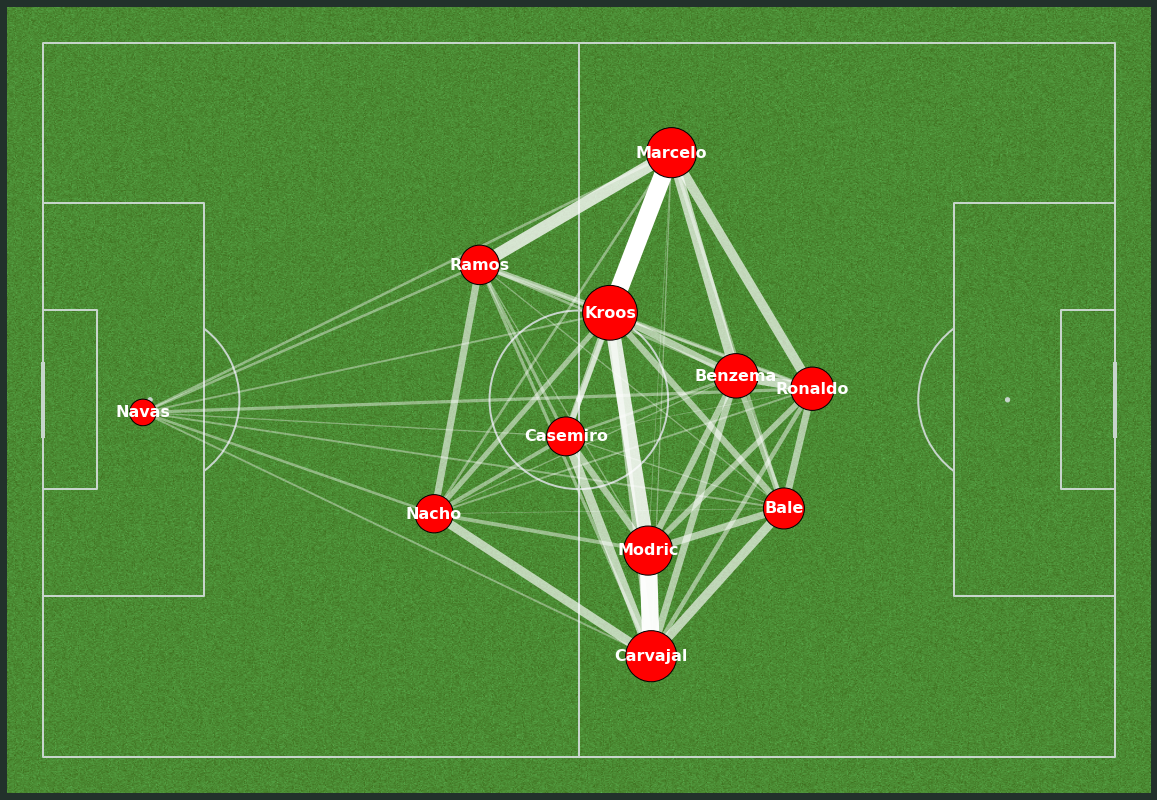

In [14]:
pitch = Pitch(pitch_type='statsbomb', pitch_color='grass', line_color='#c7d5cc')
fig, ax = pitch.draw(figsize=(16, 11), constrained_layout=True, tight_layout=False)
fig.set_facecolor("#22312b")
pass_lines = pitch.lines(passes_between.x, passes_between.y,
                         passes_between.x_end, passes_between.y_end, lw=passes_between.width,
                         color=color, zorder=1, ax=ax)
pass_nodes = pitch.scatter(average_locs_and_count.x, average_locs_and_count.y,
                           s=average_locs_and_count.marker_size,
                           color='red', edgecolors='black', linewidth=1, alpha=1, ax=ax)
for index, row in average_locs_and_count.iterrows():
    pitch.annotate(row.name, xy=(row.x, row.y), c='white', va='center',
                   ha='center', size=16, weight='bold', ax=ax)

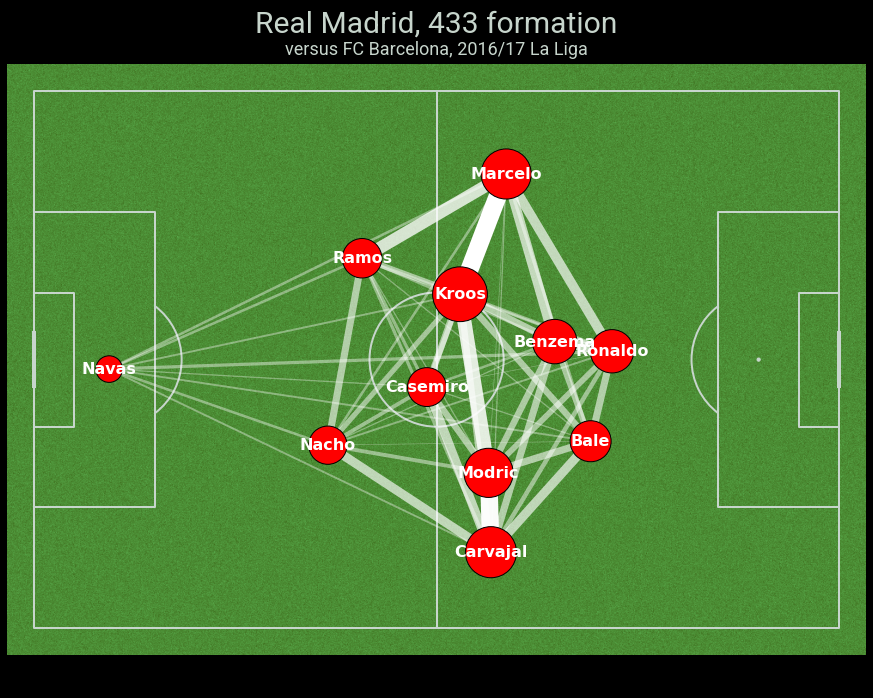

In [17]:
fig, axs = pitch.grid(figheight=10, title_height=0.08, endnote_space=0,
                      # Turn off the endnote/title axis. I usually do this after
                      # I am happy with the chart layout and text placement
                      axis=False,
                      title_space=0, grid_height=0.82, endnote_height=0.05)
fig.set_facecolor("black")
pass_lines = pitch.lines(passes_between.x, passes_between.y,
                         passes_between.x_end, passes_between.y_end, lw=passes_between.width,
                         color=color, zorder=1, ax=axs['pitch'])
pass_nodes = pitch.scatter(average_locs_and_count.x, average_locs_and_count.y,
                           s=average_locs_and_count.marker_size,
                           color='red', edgecolors='black', linewidth=1, alpha=1, ax=axs['pitch'])
for index, row in average_locs_and_count.iterrows():
    pitch.annotate(row.name, xy=(row.x, row.y), c='white', va='center',
                   ha='center', size=16, weight='bold', ax=axs['pitch'])

# Load a custom font.
URL = 'https://github.com/google/fonts/blob/main/apache/roboto/Roboto%5Bwdth,wght%5D.ttf?raw=true'
robotto_regular = FontManager(URL)

# endnote /title
axs['endnote'].text(1, 0.5, '', color='#c7d5cc',
                    va='center', ha='right', fontsize=15,
                    fontproperties=robotto_regular.prop)
TITLE_TEXT = f'{TEAM}, {FORMATION} formation'
axs['title'].text(0.5, 0.7, TITLE_TEXT, color='#c7d5cc',
                  va='center', ha='center', fontproperties=robotto_regular.prop, fontsize=30)
axs['title'].text(0.5, 0.25, OPPONENT, color='#c7d5cc',
                  va='center', ha='center', fontproperties=robotto_regular.prop, fontsize=18)



fig.savefig('pass_network_rma.jpg',dpi=1200)